Portfolio Optimization

Calculates the Mean Annual Return, Portfolio Mean, and the Covarience Matrix of the Returns

In [8]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


stock = yf.download(tickers=["AAPL", "MSFT", "PFE", "ADBE", "NVDA"], start="2013-01-01", end="2023-12-01", progress=False, auto_adjust= False)["Close"]

# Gets the percent change from the stocks
returns = stock.pct_change().dropna()
weights = np.array([0.25, 0.30, 0.10, 0.20, 0.15])

# Gains the overall mean and the covarience Matrix
meanAnnualReturns = returns.mean() * 252
portfolioMean = weights.T @ meanAnnualReturns

covMatrix = returns.cov()

print(portfolioMean)
print(covMatrix)

0.2992051677214945
Ticker      AAPL      ADBE      MSFT      NVDA       PFE
Ticker                                                  
AAPL    0.000322  0.000197  0.000189  0.000267  0.000072
ADBE    0.000197  0.000395  0.000229  0.000325  0.000080
MSFT    0.000189  0.000229  0.000288  0.000281  0.000080
NVDA    0.000267  0.000325  0.000281  0.000796  0.000081
PFE     0.000072  0.000080  0.000080  0.000081  0.000193


Calculates the transition costs, signal returns, leverage, sharpe ratio, portfolio standard deviation, and portfolio mean

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.download(tickers=["AAPL", "MSFT", "PFE", "ADBE", "NVDA"], start="2013-01-01", end="2023-12-01", progress=False, auto_adjust= False)["Close"]

signals = (stock.rolling(50).mean() > stock.rolling(200).mean()).astype(int).replace(0, -1)

# Calculates the returns gained from the stock prices
returns = stock.pct_change().dropna()

# Calculates the weights
weights = np.array([0.25, 0.30, 0.10, 0.20, 0.15])

# Gains the Annual mean from the returns for every trading day
meanAnnualReturns = returns.mean() * 252

# Calculates the overall portfolio mean and the weights transposed
portfolioMean = weights.T @ meanAnnualReturns.values

# gets the covarience Matrix from the returns
covMatrix = returns.cov()

# Gets the signal return
signalReturns = signals.shift(1) * returns

# Leverage
realized_vol = returns.rolling(20).std() * np.sqrt(252)
targetVol = 0.15

# scaling factor = target vol / realized vol
leverage = targetVol / realized_vol

# fill missing values and cap extreme leverage
leverage = leverage.fillna(1.0).clip(upper=5.0)

# Gets the cost and the transition costs
costs = signals.diff().abs() 
transitionCosts = costs.reindex(returns.index).fillna(0) * costs

portfolioReturn = (signalReturns * leverage).fillna(0) - transitionCosts.fillna(0)

# Gets the standard deviation of the portfolio
portfolioStd = np.sqrt(weights.T @ covMatrix @ weights) * np.sqrt(252)

print(signalReturns)
print(realized_vol)
print(leverage)
print(transitionCosts)
print(portfolioReturn)
print(portfolioStd)

Ticker          AAPL      ADBE      MSFT      NVDA       PFE
Date                                                        
2013-01-02       NaN       NaN       NaN       NaN       NaN
2013-01-03  0.012622  0.015389  0.013396 -0.000786  0.002316
2013-01-04  0.027855 -0.010066  0.018716 -0.032993 -0.004255
2013-01-07  0.005882  0.004983  0.001870  0.028897 -0.000770
2013-01-08 -0.002691 -0.005272  0.005245  0.021926 -0.001540
...              ...       ...       ...       ...       ...
2023-11-24 -0.007004 -0.000468 -0.001112 -0.019295 -0.005937
2023-11-27 -0.000948 -0.000258  0.003126  0.009754  0.011803
2023-11-28  0.003214  0.006540  0.010803 -0.008727  0.014930
2023-11-29 -0.005410 -0.009514 -0.010060  0.006671 -0.013136
2023-11-30  0.003063 -0.010334  0.000158 -0.028459 -0.012965

[2748 rows x 5 columns]
Ticker          AAPL      ADBE      MSFT      NVDA       PFE
Date                                                        
2013-01-03       NaN       NaN       NaN       NaN       NaN

Calculates the Markowitz, and Frontier

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.download(tickers=["AAPL", "MSFT", "PFE", "ADBE", "NVDA"], start="2013-01-01", end="2023-12-01", progress=False, auto_adjust= False)["Close"]

signals = (stock.rolling(50).mean() > stock.rolling(200).mean()).astype(int).replace(0, -1)

returns = stock.pct_change().dropna()
weights = np.array([0.25, 0.30, 0.10, 0.20, 0.15])
covMatrix = returns.cov()

# Markowitz
meanAnnualReturns = returns.mean() * 252
portfolioMean = weights.T @ meanAnnualReturns
portfolioStd = np.sqrt(weights.T @ covMatrix @ weights) * np.sqrt(252)
sharpe = portfolioMean/portfolioStd

# Frontier
portfolioVal = np.sqrt(weights.T @ covMatrix @ weights)

print("Sharpe Ratio:", sharpe)
print("Portfolio Value",portfolioVal)

Sharpe Ratio: 1.2059922595646044
Portfolio Value 0.015628751987225336


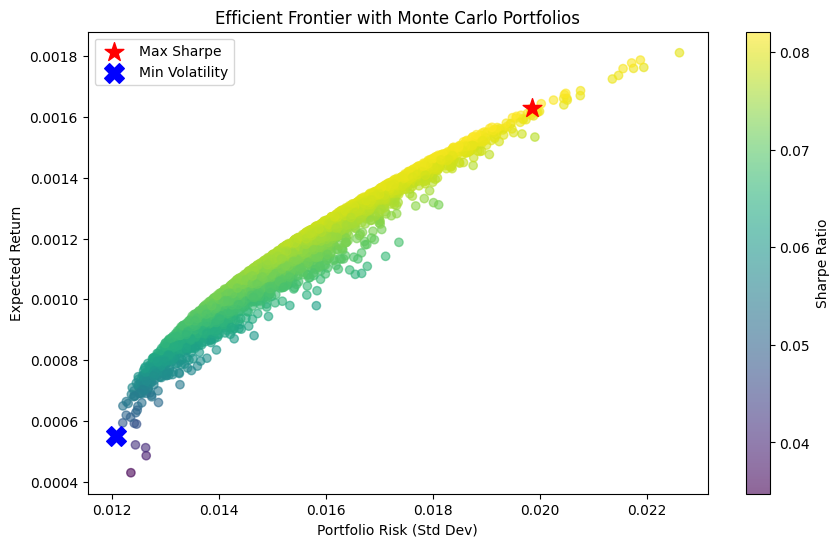

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.download(tickers=["AAPL", "MSFT", "PFE", "ADBE", "NVDA"], start="2013-01-01", end="2023-12-01", progress=False, auto_adjust= False)["Close"]

n_portfolios = 5000
results = np.zeros((3, n_portfolios))
weight_records = []

returns = stock.pct_change().dropna()

# Calculates the weights
weights = np.array([0.25, 0.30, 0.10, 0.20, 0.15])

# Gains the Annual mean from the returns for every trading day
meanAnnualReturns = returns.mean() * 252

for i in range(n_portfolios):
    weights = np.random.random(5)
    weights /= np.sum(weights)
    weight_records.append(weights)
    
    port_return = np.dot(weights, returns.mean())
    port_std = np.sqrt(weights.T @ returns.cov() @ weights)
    sharpe_ratio = port_return / port_std
    
    results[0,i] = port_return
    results[1,i] = port_std
    results[2,i] = sharpe_ratio

returns_array, risk_array, sharpe_array = results

# Max Sharpe & Min Volatility
max_sharpe_idx = sharpe_array.argmax()
min_vol_idx = risk_array.argmin()

plt.figure(figsize=(10,6))
plt.scatter(risk_array, returns_array, c=sharpe_array, cmap='viridis', alpha=0.6)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(risk_array[max_sharpe_idx], returns_array[max_sharpe_idx], color='r', marker='*', s=200, label='Max Sharpe')
plt.scatter(risk_array[min_vol_idx], returns_array[min_vol_idx], color='b', marker='X', s=200, label='Min Volatility')
plt.xlabel("Portfolio Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Monte Carlo Portfolios")
plt.legend()
plt.show()


Graph for Stock Prices

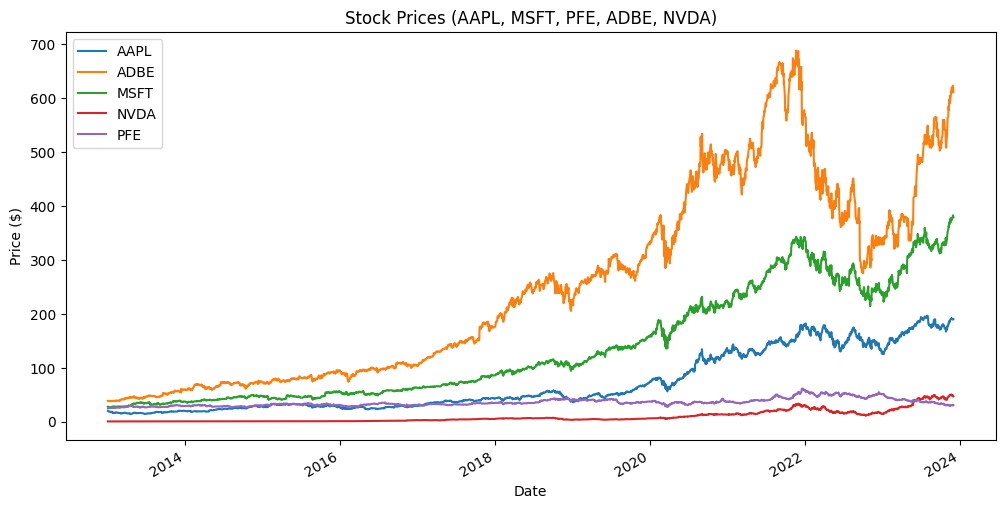

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.download(tickers=["AAPL", "MSFT", "PFE", "ADBE", "NVDA"], start="2013-01-01", end="2023-12-01", progress=False, auto_adjust= False)["Close"]

stock.plot(figsize=(12,6))
plt.title("Stock Prices (AAPL, MSFT, PFE, ADBE, NVDA)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

Graph for All Returns

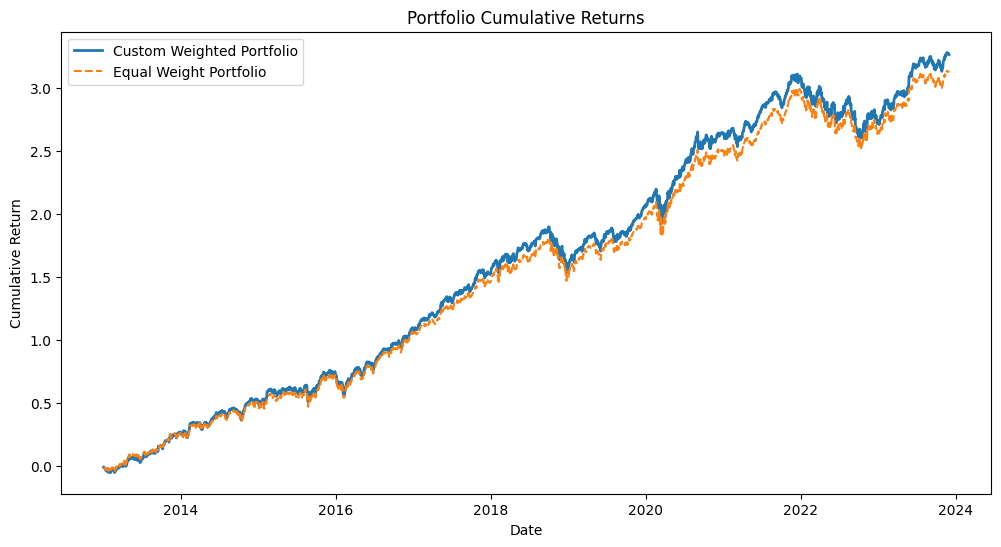

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.download(tickers=["AAPL", "MSFT", "PFE", "ADBE", "NVDA"], start="2013-01-01", end="2023-12-01", progress=False, auto_adjust= False)["Close"]

signals = (stock.rolling(50).mean() > stock.rolling(200).mean()).astype(int).replace(0, -1)

returns = stock.pct_change().dropna()
weights = np.array([0.25, 0.30, 0.10, 0.20, 0.15])
covMatrix = returns.cov()

portfolio_returns = (returns @ weights).cumsum()
equal_weight_returns = (returns @ np.ones(len(weights))/len(weights)).cumsum()

plt.figure(figsize=(12,6))
plt.plot(portfolio_returns, label="Custom Weighted Portfolio", linewidth=2)
plt.plot(equal_weight_returns, label="Equal Weight Portfolio", linestyle="--")
plt.title("Portfolio Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()